# MPG Bivariate Analysis — Example
Demonstrates `plot_data_by_varname` with sample data from the MPG dataset.

In [5]:
from src.bivariate_functions import categorize_into_deciles_with_stats, plot_data_by_varname, plot_interactive_panel
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the mtcars dataset
df = sns.load_dataset('mpg').dropna()  # Using mpg as a car-related dataset
display(df)
# Define the target column and columns to drop
target_column = "mpg"  # Miles per gallon as the target column
drop_cols = ["name"]

# Validate input columns
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' is not in the DataFrame.")
for col in drop_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' in drop_cols is not in the DataFrame.")
df["origin"]=df["origin"].astype(str)

# Initialize an empty DataFrame to store results
bivariate_statistics = pd.DataFrame()
visualizations = {}

# Identify columns to evaluate
cols_to_evaluate = list(set(df.columns) - set([target_column]) - set(drop_cols))

# Analyze each column
for column in cols_to_evaluate:
    print(f"column: {column}")
    result = categorize_into_deciles_with_stats(
        df, column, target_column, n_deciles=10, f_decile_tree=True
    )
    bivariate_statistics = pd.concat([bivariate_statistics, result], ignore_index=True)

display(bivariate_statistics)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


column: displacement
81
column: acceleration
95
column: weight
346
column: cylinders
5
column: model_year
13
column: horsepower
93
column: origin


,X_decile,varname,X_min,X_max,X_median,X_25%,X_75%,mpg_mean,mpg_std,mpg_median,mpg_25%,mpg_75%,n,n_percentage,gen_mpg_mean,discr,max_discr,x_string
0,0,displacement,68.0,91.0,86.00,79.000,90.00,33.063636,6.171931,32.00,29.900,37.250,55,14.030612,23.445918,0.410209,0.410209,[68-91]
1,1,displacement,96.0,112.0,98.00,97.000,105.00,30.116923,4.573448,29.90,27.000,33.700,65,16.581633,23.445918,0.284527,0.410209,[96-112]
2,2,displacement,113.0,135.0,121.00,119.000,122.00,25.720755,4.956323,24.00,22.000,28.000,53,13.520408,23.445918,0.097025,0.410209,[113-135]
3,3,displacement,140.0,183.0,151.00,140.000,156.00,24.883673,3.957448,25.10,23.000,27.000,49,12.500000,23.445918,0.061322,0.410209,[140-183]
4,4,displacement,198.0,267.0,232.00,225.000,250.00,19.319444,3.059211,19.00,18.000,20.500,72,18.367347,23.445918,0.176000,0.410209,[198-267]
5,5,displacement,302.0,318.0,305.00,302.500,318.00,15.290476,2.466142,15.00,14.000,17.375,42,10.714286,23.445918,0.347841,0.410209,[302-318]
6,6,displacement,340.0,455.0,360.00,350.000,400.00,14.267857,2.655704,14.00,13.000,15.000,56,14.285714,23.445918,0.391457,0.410209,[340-455]
7,0,acceleration,8.0,12.1,11.35,10.625,11.90,15.609524,4.735018,14.00,13.000,16.000,42,10.714286,23.445918,0.334233,0.334233,[8-12]
8,1,acceleration,12.2,13.7,13.00,12.800,13.50,18.735714,6.049506,17.50,14.000,21.500,56,14.285714,23.445918,0.200897,0.334233,[12-14]
9,2,acceleration,13.8,15.3,14.50,14.200,14.90,25.014444,7.988750,25.00,18.125,30.800,90,22.959184,23.445918,0.066900,0.334233,[14-15]


## Plot all variables

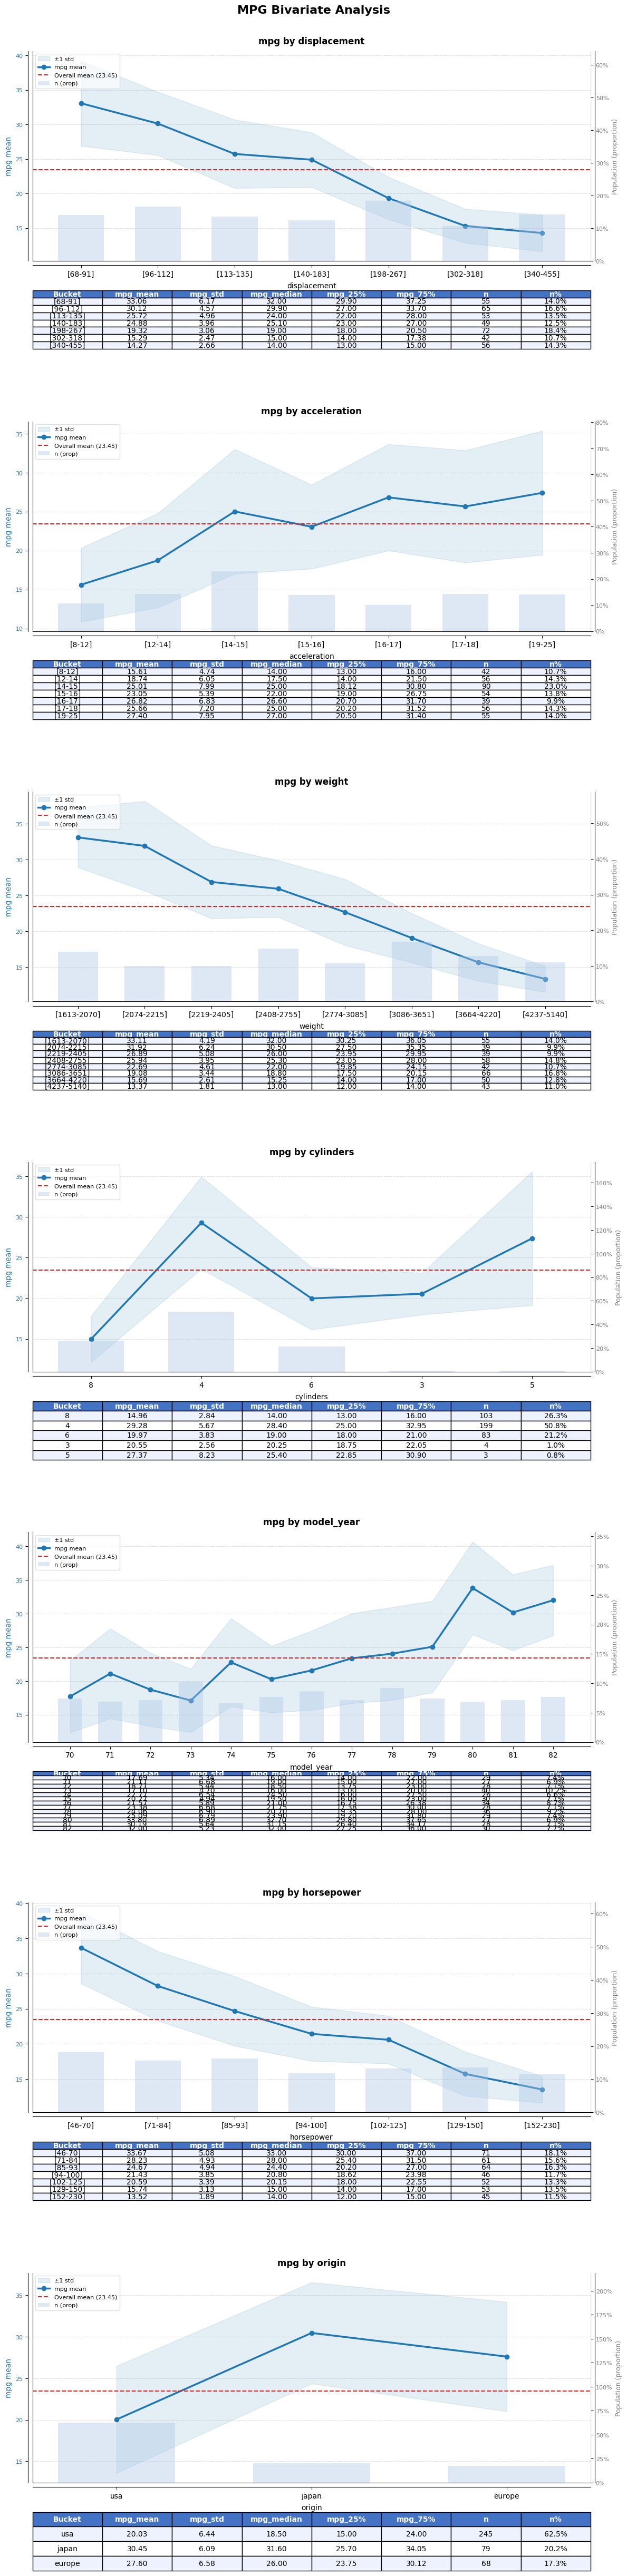

In [7]:
df = bivariate_statistics.copy()
Y = 'mpg'
vars_to_plot = df['varname'].unique().tolist()

n_vars = len(vars_to_plot)
fig, axes = plt.subplots(nrows=n_vars, ncols=1, figsize=(12, 7 * n_vars))
if n_vars == 1:
    axes = [axes]

for ax, var in zip(axes, vars_to_plot):
    plot_data_by_varname(ax, df, var, Y)

fig.suptitle('MPG Bivariate Analysis', fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout(h_pad=6)
plt.savefig('bivariate_mpg.png', dpi=150, bbox_inches='tight')
plt.show()

## Interactive Panel — max_discr filter + variable selector

Two controls let you explore manually:

| Widget | What it does |
|---|---|
| **Min max_discr slider** | Raises the minimum discrepancy threshold — only variables with `max_discr ≥ threshold` appear in the dropdown. Drag right to keep only the most discriminating variables. |
| **Variable dropdown** | Choose any surviving variable. Options are sorted by `max_discr` (highest first) and show the score next to the name, e.g. `cylinders  (discr=0.421)`. |

The chart updates immediately whenever either control changes.

In [ ]:
plot_interactive_panel(bivariate_statistics, 'mpg')